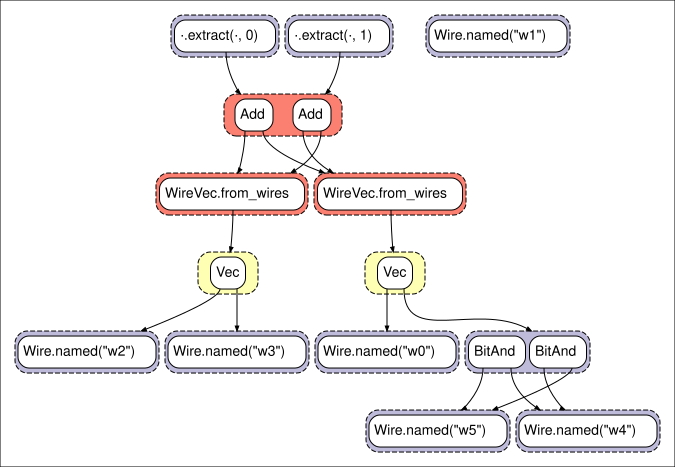

In [26]:
from __future__ import annotations
import egglog


class Wire(egglog.Expr):
    @classmethod
    def named(cls, name: egglog.StringLike) -> Wire: ...

class WireVec(egglog.Expr):
    @classmethod
    def from_wires(cls, wires: egglog.Vec[Wire]) -> WireVec: ...

    def extract(self, index: egglog.i64Like) -> Wire: ...


@egglog.function(egg_fn="Add")
def Add(left: WireVec, right: WireVec) -> WireVec: ...

@egglog.function(egg_fn="BitAnd")
def BitAnd(left: Wire, right: Wire) -> Wire: ...

egraph = egglog.EGraph()
wv0, wv1 = egglog.vars_("wv0 wv1", WireVec)
w0, w1 = egglog.vars_("w0 w1", Wire)

egraph.register(
    egglog.rewrite(Add(wv0, wv1)).to(Add(wv1, wv0)),
    egglog.rewrite(BitAnd(w0, w1)).to(BitAnd(w1, w0))
)

ws = [egraph.let(f"w{i}", Wire.named(f"w{i}")) for i in range(6)]

add0 = egraph.let("add0", Add(WireVec.from_wires(egglog.Vec(ws[0], BitAnd(ws[5], ws[4]))), WireVec.from_wires(egglog.Vec(*ws[2:4]))))
out0 = egraph.let("out0", add0.extract(egglog.i64(0)))
out1 = egraph.let("out1", add0.extract(egglog.i64(1)))

egraph.run(10)

egraph.display(graphviz=True)